# Task 1 - CNN For Image Classification

In [1]:
from datasets import load_dataset
from PIL import Image
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_curve
import numpy as np
import seaborn as sns

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ds = load_dataset("pantelism/cats-vs-dogs")
print(ds)
print(ds['train'][0])


/workspaces/eng-ai-agents/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 4000
    })
})
{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=490x500 at 0x76227E850890>, 'label': 0}


In [2]:
transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5, ))
])

class CatsDogsDataset(Dataset):
    def __init__(self, dataset_split, transform=None):
        self.dataset_split = dataset_split
        self.transform = transform

    def __len__(self):
        return len(self.dataset_split)

    def __getitem__(self, idx):
        sample = self.dataset_split[idx]
        if isinstance(sample['image'], tuple):
            sample = sample[0]

        image = sample['image']
        label = sample['label']

        if self.transform:
            image = self.transform(image)
        return image, label

full_dataset = ds['train']
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

train_dataset = CatsDogsDataset(train_subset, transform=transform)
val_dataset = CatsDogsDataset(val_subset, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)


In [3]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = SimpleCNN()
print(model) #model summary


SimpleCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=128, bias=True)
    (2): ReLU()
    (3): Linear(in_features=128, out_features=1, bias=True)
    (4): Sigmoid()
  )
)


In [4]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
#n_epochs = 5 # for testting purposes
n_epochs = 10

train_losses,val_losses = [],[]
train_accs,val_accs = [],[]

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for inputs,labels in train_loader:
        inputs,labels = inputs, labels.unsqueeze(1).float()

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        preds = (outputs > 0.5).float()
        correct += (preds == labels.unsqueeze(1)).sum().item()
        total += labels.size(0)
    train_losses.append(running_loss / len(train_loader))
    train_acc = correct / total
    train_accs.append(train_acc)

    model.eval()
    val_loss,correct, total = 0.0,0,0
    with torch.no_grad():
        for inputs,labels in val_loader:
            inputs,labels = inputs, labels.unsqueeze(1).float()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            preds = (outputs > 0.5).float()
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_losses.append(val_loss / len(val_loader))
    val_accs.append(correct / total)
    accuracy = correct / total
    print(f"Epoch {epoch+1}/{n_epochs}, Train Loss: {train_losses[-1]:.4f}, "
          f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {accuracy:.4f}")


Epoch 1/10, Train Loss: 21.5875, Val Loss: 0.6406, Val Acc: 0.6312
Epoch 2/10, Train Loss: 18.7042, Val Loss: 0.5699, Val Acc: 0.7087
Epoch 3/10, Train Loss: 16.5912, Val Loss: 0.5510, Val Acc: 0.7375
Epoch 4/10, Train Loss: 14.8842, Val Loss: 0.5417, Val Acc: 0.7250
Epoch 5/10, Train Loss: 13.2225, Val Loss: 0.5345, Val Acc: 0.7538
Epoch 6/10, Train Loss: 11.5605, Val Loss: 0.5600, Val Acc: 0.7288
Epoch 7/10, Train Loss: 9.5529, Val Loss: 0.6095, Val Acc: 0.7350
Epoch 8/10, Train Loss: 8.6414, Val Loss: 0.6388, Val Acc: 0.7288
Epoch 9/10, Train Loss: 6.4320, Val Loss: 0.7204, Val Acc: 0.7250
Epoch 10/10, Train Loss: 4.7832, Val Loss: 0.8557, Val Acc: 0.7300


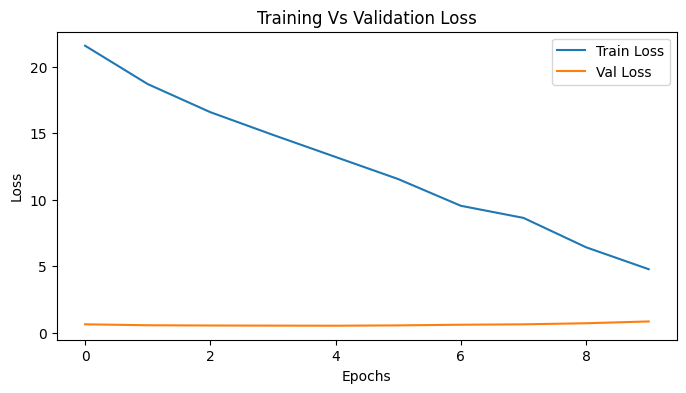

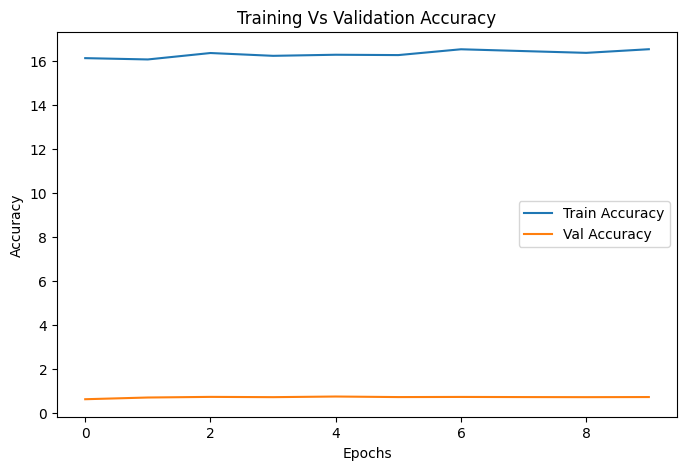

In [10]:
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Vs Validation Loss')
plt.legend()
plt.show() #Plots for both training and validation loss

plt.figure(figsize=(8,5))
plt.plot(train_accs, label='Train Accuracy')
plt.plot(val_accs, label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training Vs Validation Accuracy')
plt.legend()
plt.show()


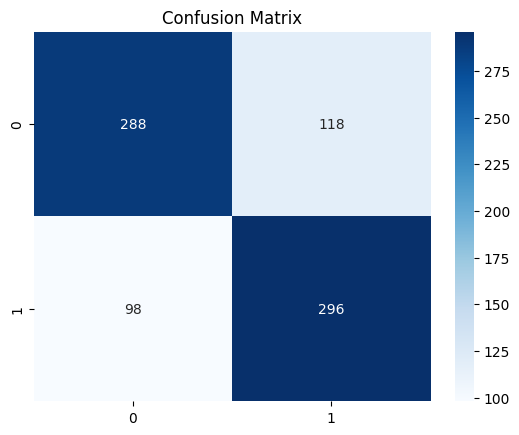

              precision    recall  f1-score   support

         Cat       0.75      0.71      0.73       406
         Dog       0.71      0.75      0.73       394

    accuracy                           0.73       800
   macro avg       0.73      0.73      0.73       800
weighted avg       0.73      0.73      0.73       800



In [11]:
all_preds, all_labels = [], []

model.eval()
with torch.no_grad():
    for inputs, labels in val_loader:
        outputs = model(inputs)
        preds = (outputs > 0.5).int()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.unsqueeze(1).numpy())

cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(all_labels, all_preds, target_names=['Cat', 'Dog']))


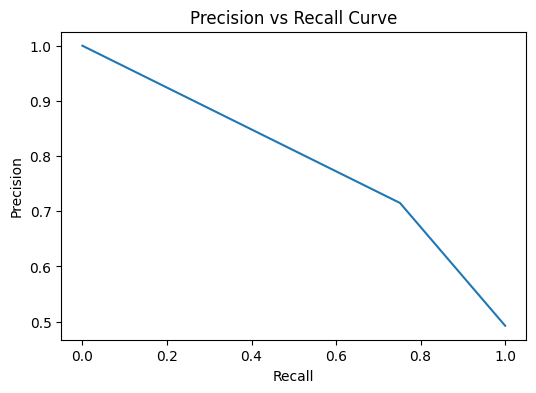

In [12]:
y_true = np.array(all_labels).ravel()
y_pred = np.array(all_preds).ravel()

precision, recall, _ = precision_recall_curve(y_true, y_pred)

plt.figure(figsize=(6,4))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision vs Recall Curve')
plt.show()


# Task 2 - GRADCAM and OCCLUSION

### GradCAM Heatmap Interpretation

- GradCAM highlights image regions most important for the model’s prediction.
- Warm colors indicate areas with strong influence on the predicted class.
- The last convolutional layer focuses on high-level features such as shapes and object parts.
- These visualizations help us understand what the model “looks at” and build trust in its decisions.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..1.0].


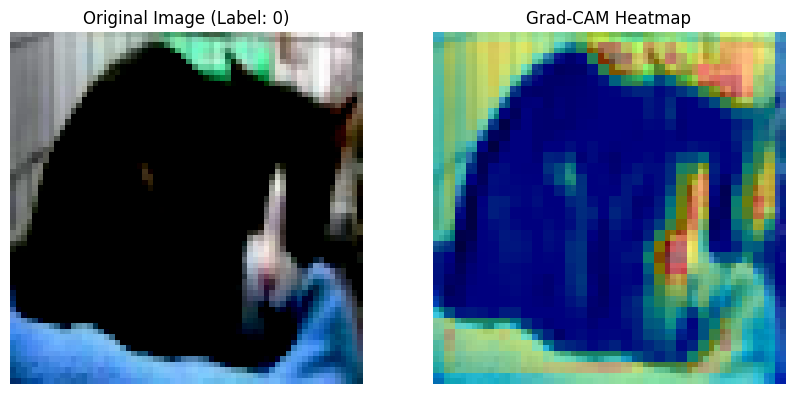

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..0.24705887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..0.24705887].


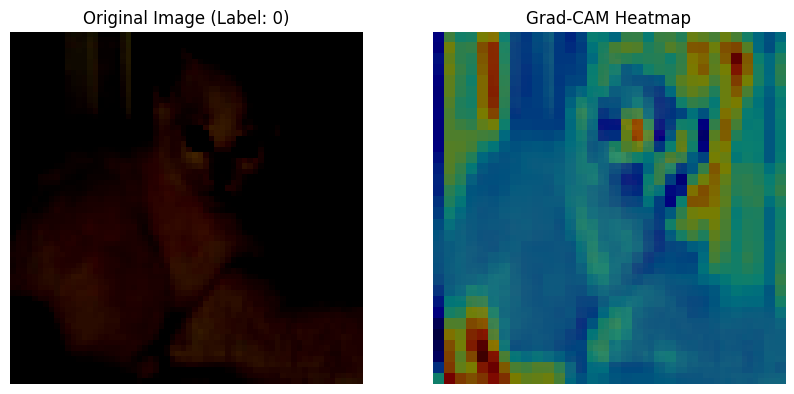

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..0.6784314].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..0.6784314].


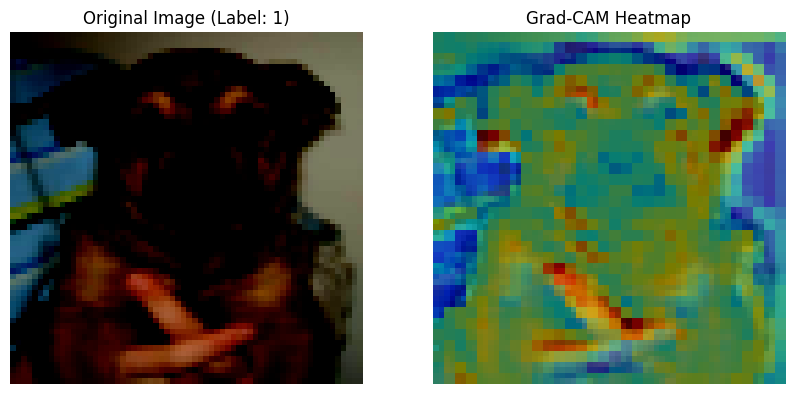

In [18]:
from captum.attr import LayerGradCam, LayerAttribution
from captum.attr import Occlusion

import matplotlib.pyplot as plt

sample_batch = next(iter(val_loader))
images = sample_batch[0][:3].to(device)        # First 3 images
labels = sample_batch[1][:3].tolist()          # Corresponding labels

model.eval()

gradcam = LayerGradCam(model, model.conv_layers[3])  # last conv layer

for i in range(3):
    input_tensor = images[i].unsqueeze(0)  # Add batch dimension

    attribution = gradcam.attribute(input_tensor, target=0)

    upsampled_attr = LayerAttribution.interpolate(attribution, input_tensor.shape[2:])
    attr = upsampled_attr.squeeze().detach().cpu().numpy()

    atr_norm = (attr - attr.min()) / (attr.max() - attr.min())

    img = images[i].detach().cpu().permute(1, 2, 0).numpy()

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title(f"Original Image (Label: {labels[i]})")
    plt.imshow(img)
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.title("Grad-CAM Heatmap")
    plt.imshow(img)
    plt.imshow(atr_norm, cmap="jet", alpha=0.5)
    plt.axis("off")
    plt.show()


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..1.0].



Occlusion mask 1 with sliding_window_shapes=(3, 10, 10)
Image 0 - Original Prediction score: 0.4999


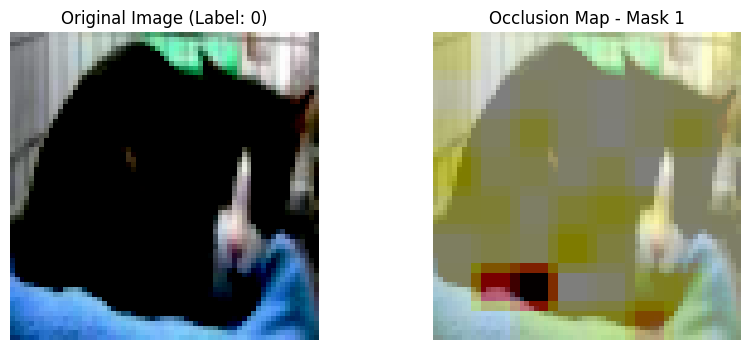

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..0.24705887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..0.24705887].


Image 1 - Original Prediction score: 0.3199


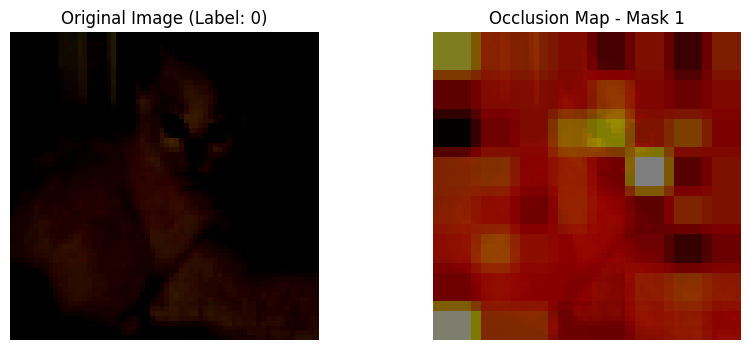

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..0.6784314].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..0.6784314].


Image 2 - Original Prediction score: 0.7305


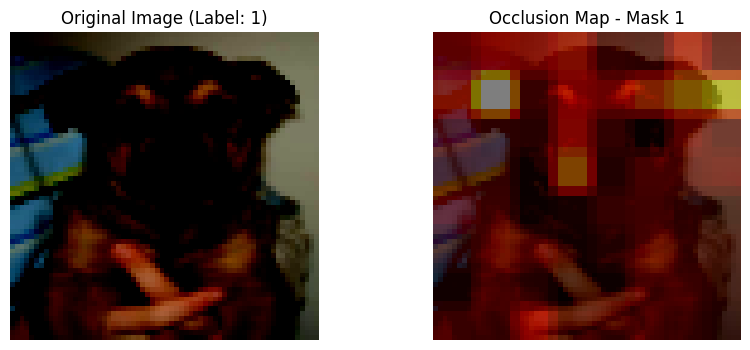

Accuracy with occlusion mask 1: 0.33

Occlusion mask 2 with sliding_window_shapes=(3, 15, 15)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..1.0].


Image 0 - Original Prediction score: 0.4999


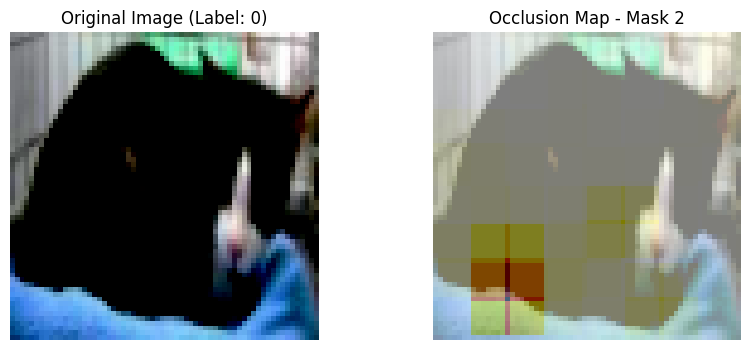

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..0.24705887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..0.24705887].


Image 1 - Original Prediction score: 0.3199


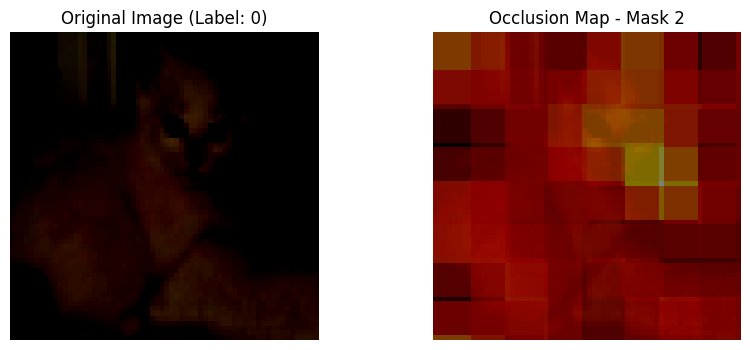

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..0.6784314].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..0.6784314].


Image 2 - Original Prediction score: 0.7305


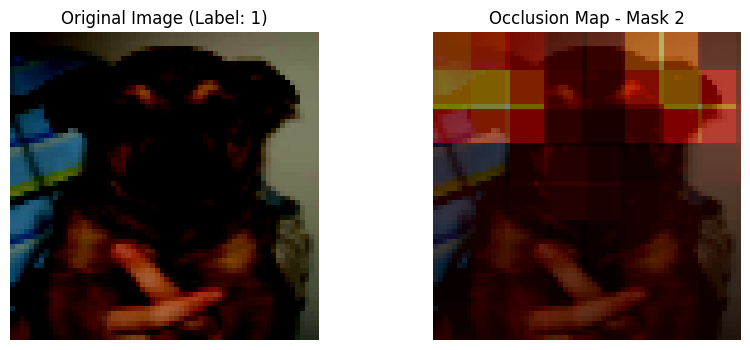

Accuracy with occlusion mask 2: 0.33

Occlusion mask 3 with sliding_window_shapes=(3, 20, 20)


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..1.0].


Image 0 - Original Prediction score: 0.4999


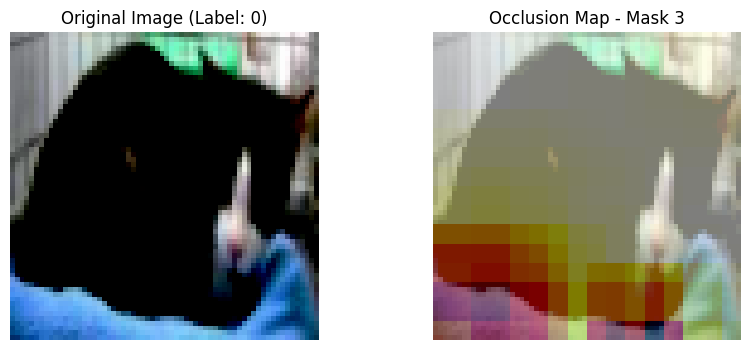

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..0.24705887].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9529412..0.24705887].


Image 1 - Original Prediction score: 0.3199


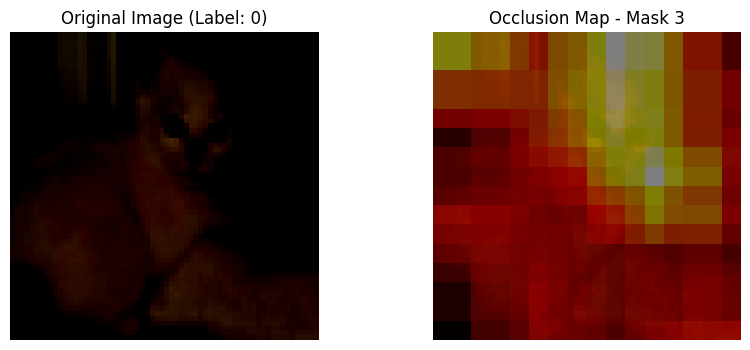

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..0.6784314].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..0.6784314].


Image 2 - Original Prediction score: 0.7305


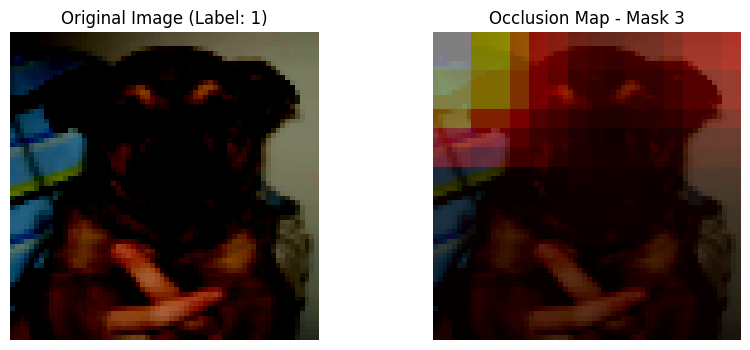

Accuracy with occlusion mask 3: 0.33


In [19]:
occlusion = Occlusion(model)

# Define 3 different occlusion masks (sliding window shapes)
occlusion_masks = [(3, 10, 10), (3, 15, 15), (3, 20, 20)]

for mask_num, window_shape in enumerate(occlusion_masks, 1):
    correct = 0
    print(f"\nOcclusion mask {mask_num} with sliding_window_shapes={window_shape}")

    for i in range(3):
        input_tensor = images[i].unsqueeze(0)  # Add batch dimension
        target = int(labels[i])  # 0 or 1

        model.eval()
        with torch.no_grad():
            output = model(input_tensor).squeeze()
            prob_class1 = torch.sigmoid(output).item()
            if target == 1:
                orig_score = prob_class1
            else:
                orig_score = 1 - prob_class1

            # Prediction based on threshold 0.5
            pred_label = 1 if prob_class1 > 0.5 else 0
            if pred_label == target:
                correct += 1

        # Occlusion attribution with current mask
        occlusion_atr = occlusion.attribute(
            input_tensor,
            strides=(3, 8, 8),
            target=0,  # Only output node 0 exists
            sliding_window_shapes=window_shape
        )

        occlusion_map = occlusion_atr.squeeze().cpu().detach().numpy()
        occlusion_2d = occlusion_map.mean(axis=0)

        print(f"Image {i} - Original Prediction score: {orig_score:.4f}")

        img = images[i].detach().cpu().permute(1, 2, 0).numpy()

        plt.figure(figsize=(10, 4))
        plt.subplot(1, 2, 1)
        plt.title(f'Original Image (Label: {target})')
        plt.imshow(img)
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.title(f'Occlusion Map - Mask {mask_num}')
        plt.imshow(img)
        plt.imshow(occlusion_2d, cmap='hot', alpha=0.5)
        plt.axis('off')
        plt.show()

    accuracy = correct / 3
    print(f"Accuracy with occlusion mask {mask_num}: {accuracy:.2f}")


# Task 3 - Fast Gradient Sign Method for Adversarial Attacks

In [20]:
def fgsm_attack(image, epsilon, data_grad):
    sign_data_grad = data_grad.sign()
    perturbed_image = image + epsilon * sign_data_grad
    perturbed_image = torch.clamp(perturbed_image, 0, 1)
    return perturbed_image


In [21]:
def test_fgsm(model, device, test_loader, epsilon):
    correct = 0
    adv_examples = []

    model.eval()
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        data.requires_grad = True

        output = model(data)
        loss = F.binary_cross_entropy_with_logits(output.squeeze(1), target.float())
        
        model.zero_grad()
        loss.backward()
        data_grad = data.grad.data

        perturbed_data = fgsm_attack(data, epsilon, data_grad)
        output = model(perturbed_data)
        pred = torch.round(torch.sigmoid(output.squeeze(1)))

        correct += (pred == target).sum().item()

        if len(adv_examples) < 5:
            adv_img = perturbed_data[0].detach().cpu().permute(1,2,0).numpy()
            adv_examples.append((target[0].item(), pred[0].item(), adv_img))
    final_acc = correct / len(test_loader.dataset)
    print(f"Epsilon: {epsilon}\tTest Accuracy = {final_acc * 100:.2f}%")
    return final_acc,adv_examples


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
epsilons = [0.01, 0.05, 0.1]

examples = []
for eps in epsilons:
    acc, ex = test_fgsm(model, device, val_loader, eps)
    examples.append((eps, acc, ex))


Epsilon: 0.01	Test Accuracy = 49.25%
Epsilon: 0.05	Test Accuracy = 49.25%
Epsilon: 0.1	Test Accuracy = 49.25%


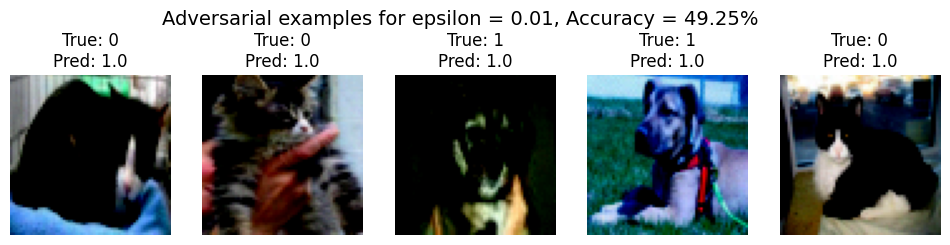

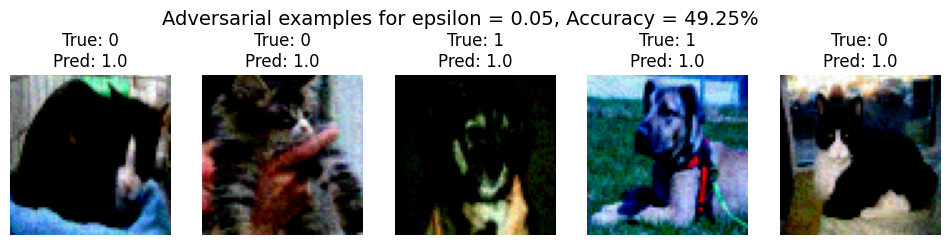

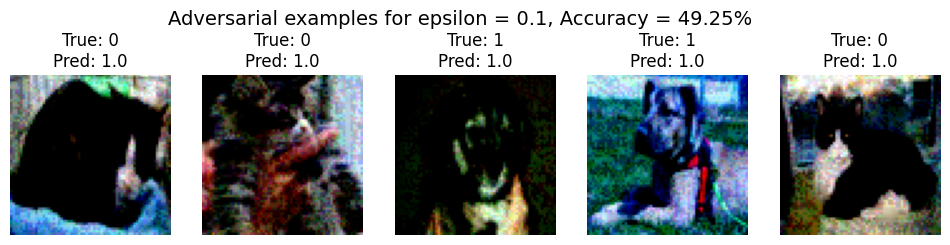

In [23]:
for eps, acc, adv_examples in examples:
    plt.figure(figsize=(12, 3))
    plt.suptitle(f"Adversarial examples for epsilon = {eps}, Accuracy = {acc*100:.2f}%", fontsize=14)

    for i, (true_label, pred_label, adv_img) in enumerate(adv_examples):
        plt.subplot(1, len(adv_examples), i + 1)
        plt.imshow(adv_img)
        plt.title(f"True: {true_label}\nPred: {pred_label}")
        plt.axis('off')
    plt.show()


# Task 4 - QRANT

In [24]:
from qdrant_client import QdrantClient
from qdrant_client.models import VectorParams, Distance,PointStruct

client = QdrantClient(":memory:")
client.recreate_collection(
    collection_name="cats_vs_dogs_embeddings",
    vectors_config=VectorParams(size=128, distance=Distance.COSINE)
)


/tmp/ipykernel_13236/665671428.py:5: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(


True

In [25]:
feature_extractor = nn.Sequential(
    *list(model.conv_layers),
    nn.Flatten(),
    model.fc_layers[0],
    model.fc_layers[1]  
)

feature_extractor.eval()
feature_extractor.to(device)

points = []
for idx in range(len(val_dataset)):
    img, label = val_dataset[idx]
    with torch.no_grad():
        emb = feature_extractor(img.unsqueeze(0)).squeeze().numpy()
    points.append(PointStruct(id=idx, vector=emb, payload={"label": int(label)}))
client.upsert(collection_name="cats_vs_dogs_embeddings", points=points)
print(f"Inserted {len(points)} embeddings into Qdrant.")


Inserted 800 embeddings into Qdrant.


/tmp/ipykernel_13236/2272426240.py:11: DeprecationWarning: `search` method is deprecated and will be removed in the future. Use `query_points` instead.
  search_result = client.search(
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9843137..0.9372549].


Query Image Index: 162


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9843137..0.9372549].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94509804..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9372549..0.79607844].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8745098..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9764706..0.6156863].


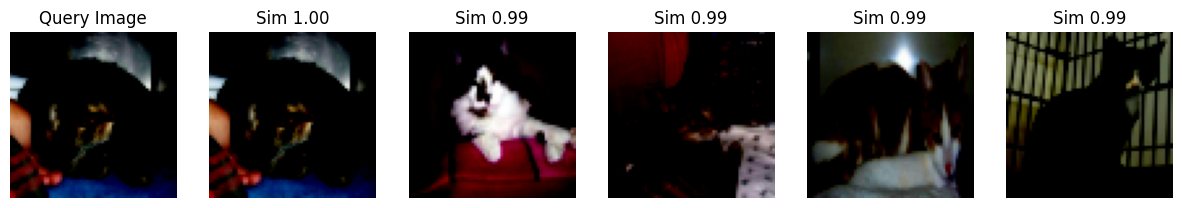

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6627451..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6627451..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94509804..0.99215686].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8901961..1.0].


Query Image Index: 269


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.96862745..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.77254903..1.0].


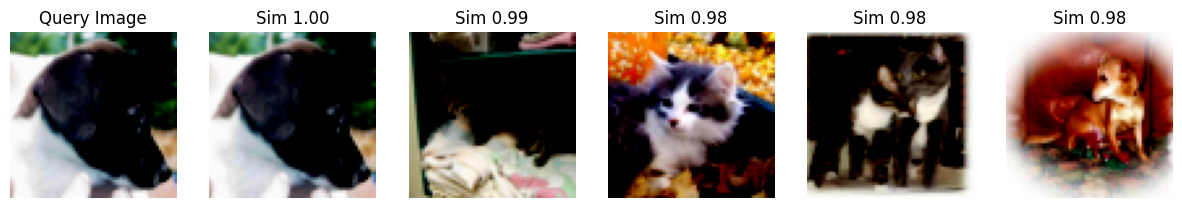

Query Image Index: 484


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9372549..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9372549..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.8980392..0.8901961].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.9137255..0.827451].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.90588236..1.0].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.94509804..1.0].


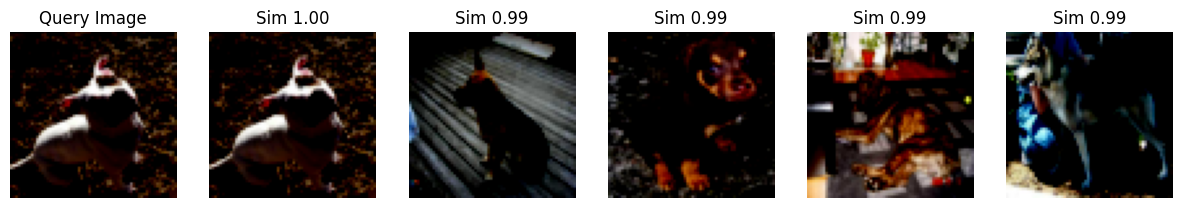

In [26]:
import random

k = 5  # Number of similar images to retrieve
random_indices = random.sample(range(len(val_dataset)), 3)  # Select 3 random image indices

for query_idx in random_indices:
    query_img, _ = val_dataset[query_idx]
    with torch.no_grad():
        query_emb = feature_extractor(query_img.unsqueeze(0)).squeeze().numpy()

    search_result = client.search(
        collection_name="cats_vs_dogs_embeddings",
        query_vector=query_emb,
        limit=k
    )

    print(f"Query Image Index: {query_idx}")
    fig, axes = plt.subplots(1, k + 1, figsize=(15, 4))
    axes[0].imshow(query_img.permute(1, 2, 0))
    axes[0].set_title("Query Image")
    axes[0].axis('off')

    for i, result in enumerate(search_result):
        idx = result.id
        match_img, _ = val_dataset[idx]
        axes[i + 1].imshow(match_img.permute(1, 2, 0))
        axes[i + 1].set_title(f"Sim {result.score:.2f}")
        axes[i + 1].axis('off')
    plt.show()
